In [14]:
import numpy as np
import matplotlib.pyplot as plt

## Problem trzech ciał (CR3BP)

Parametry:
- $\mu = 0.012150582$
- Ziemia: $(-\mu, 0)$, Ksiezyc: $(1-\mu, 0)$
- Stan poczatkowy: $(x, y, u, v) = (1.05, 0.1, -0.45, -0.25)$
- Czas symulacji: $t \in [0, 5]$

In [15]:
# ----------------------------------------------------------------
# Parametry ukladu
# ----------------------------------------------------------------

MU = np.float64(0.012150582)

X0 = np.array([1.05, 0.1, -0.45, -0.25], dtype=np.float64)  # [x, y, u, v]
T_SPAN = (np.float64(0.0), np.float64(5.0))

# Polozenia Ziemi i Ksiezyca
EARTH_POS = np.array([-MU,      0.0])
MOON_POS  = np.array([1.0 - MU, 0.0])

# Punkty libracyjne Lagrange'a
L1 = np.array([1.0 - (MU/3)**(1/3),  0.0])
L2 = np.array([1.0 + (MU/3)**(1/3),  0.0])
L3 = np.array([-(1.0 + 5*MU/12),     0.0])
L4 = np.array([0.5 - MU,             np.sqrt(3)/2])
L5 = np.array([0.5 - MU,            -np.sqrt(3)/2])

LAGRANGE_POINTS = {'L1': L1, 'L2': L2, 'L3': L3, 'L4': L4, 'L5': L5}

print("Ziemia:", EARTH_POS)
print("Ksiezyc:", MOON_POS)
for name, pt in LAGRANGE_POINTS.items():
    print(f"{name}: ({pt[0]:.6f}, {pt[1]:.6f})")

Ziemia: [-0.01215058  0.        ]
Ksiezyc: [0.98784942 0.        ]
L1: (0.840599, 0.000000)
L2: (1.159401, 0.000000)
L3: (-1.005063, 0.000000)
L4: (0.487849, 0.866025)
L5: (0.487849, -0.866025)


## Uklad rownan ruchu (RHS)

In [16]:
def cr3bp_rhs(t, state, mu=MU):
    """
    Prawa strona ukladu CR3BP.
    state = [x, y, u, v]
    Zwraca [x', y', u', v'] = [u, v, u', v']
    """
    x, y, u, v = state
    mu = np.float64(mu)

    r1 = np.sqrt((x + mu)**2       + y**2)   # odleglosc od Ziemi
    r2 = np.sqrt((x - 1.0 + mu)**2 + y**2)   # odleglosc od Ksiezyca

    dxdt = u
    dydt = v
    dudt = x + 2 * v - (((1 - mu)*(x + mu)) / r1**3 + (mu * (x - 1.0 + mu)) / r2**3)
    dvdt = y - 2 * u - (((1 - mu) * y) / r1**3 + (mu * y) / r2**3)

    return np.array([dxdt, dydt, dudt, dvdt])

## Zadanie 1a – Metody numeryczne

In [17]:
def euler_explicit(f, t_span, y0, h):
    """
    Jawna metoda Eulera.
    y_{k+1} = y_k + h * f(t_k, y_k)
    """
    t0, tf = t_span
    t = np.arange(t0, tf + h/2, h, dtype=np.float64)
    y = np.zeros((len(t), len(y0)), dtype=np.float64)
    y[0] = y0

    for k in range(len(t) - 1):
        y[k+1] = y[k] + h * f(t[k], y[k])

    return t, y


def euler_implicit(f, t_span, y0, h, mu=MU):
    """
    Niejawna metoda Eulera.
    y_{k+1} = y_k + h * f(t_{k+1}, y_{k+1})
    Rozwiazywana iteracja prosta (fixed-point iteration).
    """
    t0, tf = t_span
    t = np.arange(t0, tf + h/2, h, dtype=np.float64)
    y = np.zeros((len(t), len(y0)), dtype=np.float64)
    y[0] = y0

    for k in range(len(t) - 1):
        y_guess = y[k].copy()
        for _ in range(50):
            y_new = y[k] + h * f(t[k+1], y_guess)
            if np.linalg.norm(y_new - y_guess) < 1e-12:
                break
            y_guess = y_new
        y[k+1] = y_new

    return t, y


def euler_symplectic(f, t_span, y0, h, mu=MU):
    """
    Polujawna (symplektyczna) metoda Eulera.
    Predkosci aktualizowane jawnie, pozycje – uzywajac nowych predkosci.
    """
    t0, tf = t_span
    t = np.arange(t0, tf + h/2, h, dtype=np.float64)
    y = np.zeros((len(t), len(y0)), dtype=np.float64)
    y[0] = y0

    for k in range(len(t) - 1):
        f_k = f(t[k], y[k])
        # Krok 1: zaktualizuj predkosci (u, v) jawnie
        y_mid = y[k].copy()
        y_mid[2] += h * f_k[2]
        y_mid[3] += h * f_k[3]
        # Krok 2: zaktualizuj pozycje (x, y) uzywajac nowych predkosci
        f_mid = f(t[k], y_mid)
        y[k+1] = y[k].copy()
        y[k+1][0] += h * f_mid[0]
        y[k+1][1] += h * f_mid[1]
        y[k+1][2]  = y_mid[2]
        y[k+1][3]  = y_mid[3]

    return t, y


def rk4(f, t_span, y0, h):
    """
    Metoda Rungego-Kutty 4. rzedu (RK4).
    y_{k+1} = y_k + (h/6)*(k1 + 2k2 + 2k3 + k4)
    """
    t0, tf = t_span
    t = np.arange(t0, tf + h/2, h, dtype=np.float64)
    y = np.zeros((len(t), len(y0)), dtype=np.float64)
    y[0] = y0

    for k in range(len(t) - 1):
        k1 = f(t[k],       y[k])
        k2 = f(t[k] + h/2, y[k] + h * k1 / 2)
        k3 = f(t[k] + h/2, y[k] + h * k2 / 2)
        k4 = f(t[k] + h,   y[k] + h * k3)
        y[k+1] = y[k] + (h/6) * (k1 + 2 * k2 + 2 * k3 + k4)

    return t, y

In [18]:
# Krok czasowy i obliczenia
H = np.float64(0.001)

t_exp, y_exp  = euler_explicit(cr3bp_rhs,   T_SPAN, X0, H)
t_imp, y_imp  = euler_implicit(cr3bp_rhs,   T_SPAN, X0, H)
t_sym, y_sym  = euler_symplectic(cr3bp_rhs, T_SPAN, X0, H)
t_rk4, y_rk4  = rk4(cr3bp_rhs,             T_SPAN, X0, H)

print(f"Kroki: {len(t_rk4)}, od t={t_rk4[0]:.2f} do t={t_rk4[-1]:.2f}")
print(f"Euler jawny  – ostatni stan: x={y_exp[-1,0]:.4f}, y={y_exp[-1,1]:.4f}")
print(f"Euler niejaw – ostatni stan: x={y_imp[-1,0]:.4f}, y={y_imp[-1,1]:.4f}")
print(f"Euler sympl  – ostatni stan: x={y_sym[-1,0]:.4f}, y={y_sym[-1,1]:.4f}")
print(f"RK4          – ostatni stan: x={y_rk4[-1,0]:.4f}, y={y_rk4[-1,1]:.4f}")

Kroki: 5001, od t=0.00 do t=5.00
Euler jawny  – ostatni stan: x=0.4613, y=0.2499
Euler niejaw – ostatni stan: x=-0.0614, y=-0.1007
Euler sympl  – ostatni stan: x=-0.0690, y=0.8083
RK4          – ostatni stan: x=0.0100, y=0.8767


## Zadanie 1b – Mapa ukladu: Ziemia, Ksiezyc, punkty L1-L5

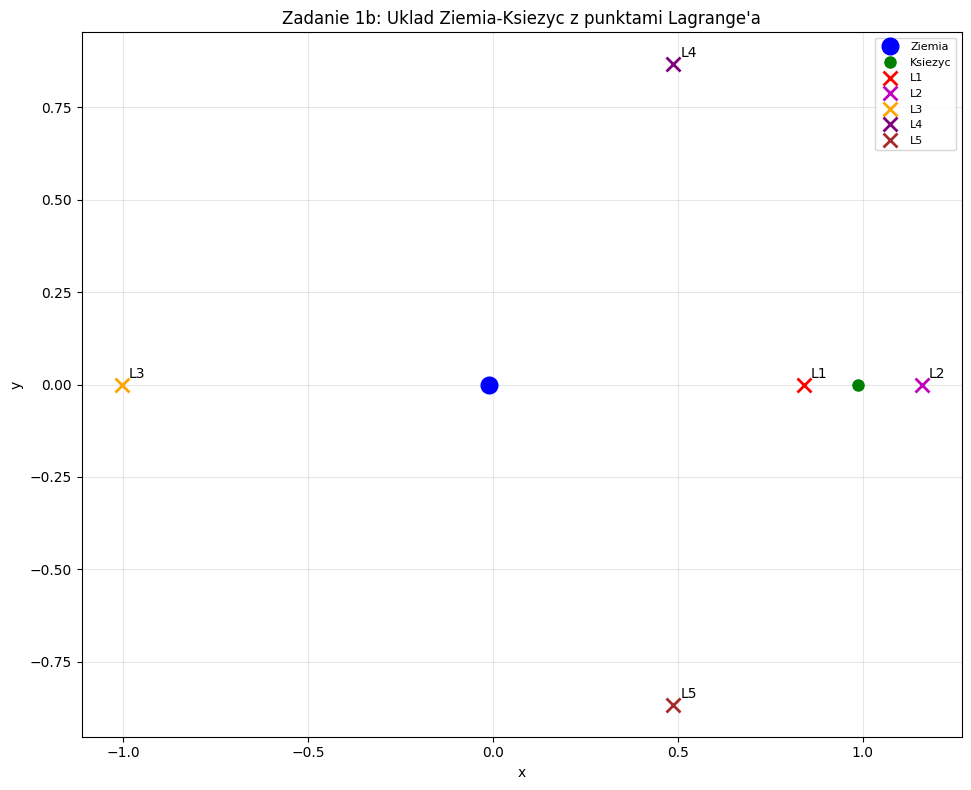

In [19]:
def plot_system_map(ax=None):
    """Rysuje mape ukladu: Ziemia, Ksiezyc i punkty Lagrange'a."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(*EARTH_POS, 'bo', markersize=12, label='Ziemia')
    ax.plot(*MOON_POS,  'go', markersize=8,  label='Ksiezyc')

    colors = ['r', 'm', 'orange', 'purple', 'brown']
    for (name, pt), col in zip(LAGRANGE_POINTS.items(), colors):
        ax.plot(*pt, 'x', color=col, markersize=10, markeredgewidth=2, label=name)
        ax.annotate(name, pt, textcoords='offset points', xytext=(5, 5))

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    return ax

fig, ax = plt.subplots(figsize=(10, 8))
plot_system_map(ax)
ax.set_title("Zadanie 1b: Uklad Ziemia-Ksiezyc z punktami Lagrange'a")
plt.tight_layout()
plt.show()

## Zadanie 1c – Trajektoria asteroidy w ukladzie synodycznym

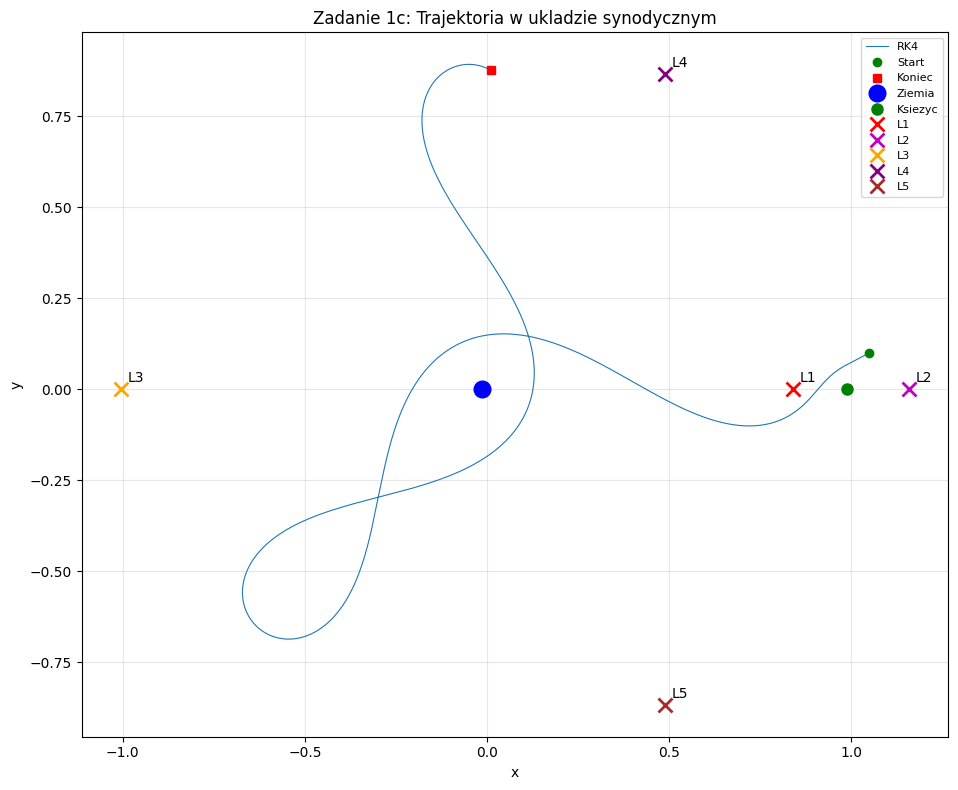

In [20]:
def plot_trajectory_synodic(t, y, label='', ax=None):
    """Rysuje trajektorie asteroidy w ukladzie synodycznym."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    ax.plot(y[:, 0], y[:, 1], '-', linewidth=0.8, label=label if label else 'Asteroida')
    ax.plot(y[0, 0],  y[0, 1],  'go', markersize=6, label='Start')
    ax.plot(y[-1, 0], y[-1, 1], 'rs', markersize=6, label='Koniec')

    plot_system_map(ax)
    ax.set_title('Zadanie 1c: Trajektoria w ukladzie synodycznym')
    ax.legend(fontsize=8)
    return ax

fig, ax = plt.subplots(figsize=(10, 8))
plot_trajectory_synodic(t_rk4, y_rk4, label='RK4', ax=ax)
plt.tight_layout()
plt.show()

## Zadanie 1d – Trajektoria w ukladzie inercjalnym

$$\begin{bmatrix} X \\\\ Y \end{bmatrix} = \begin{bmatrix} \cos t & -\sin t \\\\ \sin t & \cos t \end{bmatrix}\begin{bmatrix} x \\\\ y \end{bmatrix}$$

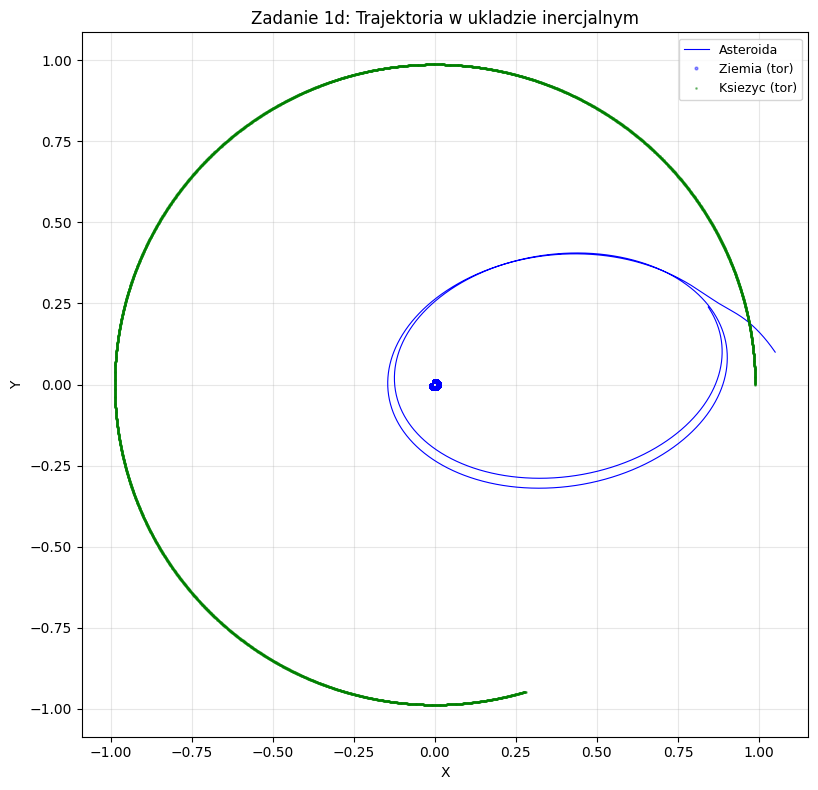

Minimalna odleglosc asteroidy od Ziemi: 0.134530 [j.u.]


In [21]:
def synodic_to_inertial_pos(t, x, y):
    """Transformuje pozycje z ukladu synodycznego do inercjalnego."""
    X = np.cos(t) * x - np.sin(t) * y
    Y = np.sin(t) * x + np.cos(t) * y
    return X, Y


def plot_inertial_trajectory(t, y):
    """Rysuje trajektorie w ukladzie inercjalnym i wyznacza min. odleglosc od Ziemi."""
    x_syn = y[:, 0]
    y_syn = y[:, 1]

    X_ast, Y_ast = synodic_to_inertial_pos(t, x_syn, y_syn)

    X_earth = np.cos(t) * EARTH_POS[0] - np.sin(t) * EARTH_POS[1]
    Y_earth = np.sin(t) * EARTH_POS[0] + np.cos(t) * EARTH_POS[1]

    X_moon = np.cos(t) * MOON_POS[0] - np.sin(t) * MOON_POS[1]
    Y_moon = np.sin(t) * MOON_POS[0] + np.cos(t) * MOON_POS[1]

    dist_to_earth = np.sqrt((X_ast - X_earth)**2 + (Y_ast - Y_earth)**2)
    min_dist = np.min(dist_to_earth)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot(X_ast,   Y_ast,   'b-', linewidth=0.8, label='Asteroida')
    ax.plot(X_earth, Y_earth, 'bo', markersize=2,  alpha=0.4, label='Ziemia (tor)')
    ax.plot(X_moon,  Y_moon,  'go', markersize=1,  alpha=0.4, label='Ksiezyc (tor)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Zadanie 1d: Trajektoria w ukladzie inercjalnym')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

    print(f"Minimalna odleglosc asteroidy od Ziemi: {min_dist:.6f} [j.u.]")

plot_inertial_trajectory(t_rk4, y_rk4)

## Zadanie 1e – Predkosc w ukladzie inercjalnym

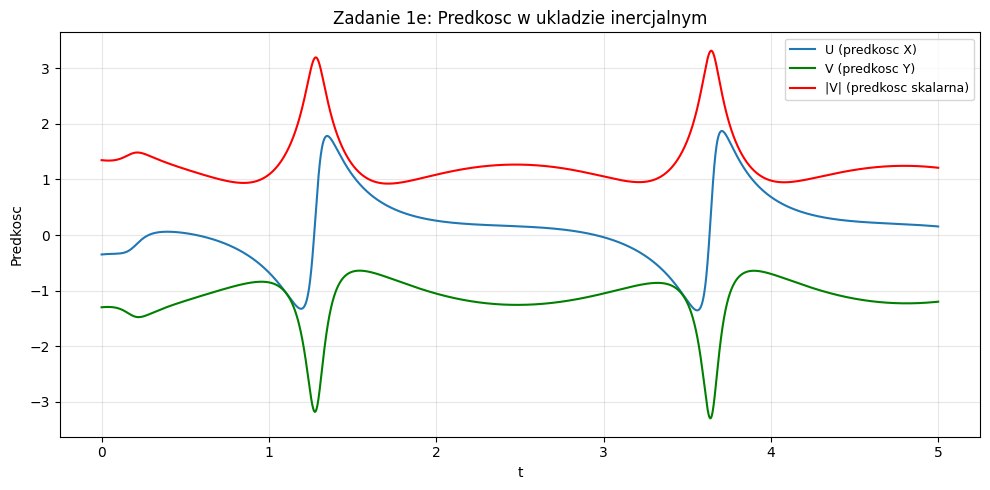

In [22]:
def synodic_to_inertial_vel(t, x, y, u, v):
    """Transformuje predkosc z ukladu synodycznego do inercjalnego."""
    U = np.cos(t)*u - np.sin(t)*v + np.sin(t)*x + np.cos(t)*y
    V = np.sin(t)*u + np.cos(t)*v - np.cos(t)*x + np.sin(t)*y
    return U, V


def plot_inertial_velocity(t, y):
    """Rysuje predkosc asteroidy w ukladzie inercjalnym."""
    x_syn, y_syn = y[:, 0], y[:, 1]
    u_syn, v_syn = y[:, 2], y[:, 3]

    U, V = synodic_to_inertial_vel(t, x_syn, y_syn, u_syn, v_syn)
    speed = np.sqrt(U**2 + V**2)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(t, U,     label='U (predkosc X)')
    ax.plot(t, V, 'g', label='V (predkosc Y)')
    ax.plot(t, speed, 'r', label='|V| (predkosc skalarna)')
    ax.set_xlabel('t')
    ax.set_ylabel('Predkosc')
    ax.set_title('Zadanie 1e: Predkosc w ukladzie inercjalnym')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_inertial_velocity(t_rk4, y_rk4)

## Zadanie 1f – Energie kinetyczna i potencjalna


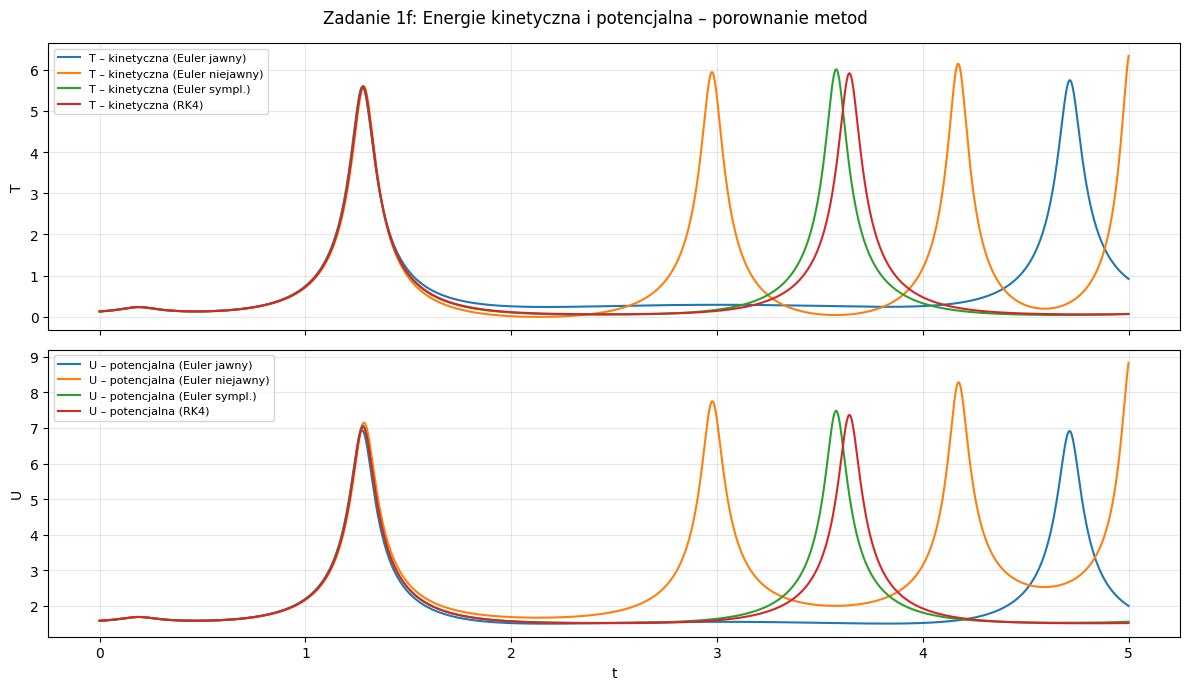

In [23]:
def compute_energies(y_sol, mu=MU):
    """Oblicza energie kinetyczna T i potencjalna U dla kazdego kroku."""
    x, y_pos, u, v = y_sol[:, 0], y_sol[:, 1], y_sol[:, 2], y_sol[:, 3]

    r1 = np.sqrt((x + mu)**2       + y_pos**2)
    r2 = np.sqrt((x - 1.0 + mu)**2 + y_pos**2)

    T = 0.5 * (u**2 + v**2)
    U = 0.5 * (x**2 + y_pos**2) + (1.0 - mu)/r1 + mu/r2

    return T, U


def plot_energies(t, y_sol, label='', mu=MU, axes=None):
    """Rysuje wykres energii kinetycznej i potencjalnej."""
    T, U = compute_energies(y_sol, mu)
    standalone = axes is None
    if standalone:
        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    axes[0].plot(t, T, label=f'T – kinetyczna ({label})')
    axes[0].set_ylabel('T')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, U, label=f'U – potencjalna ({label})')
    axes[1].set_ylabel('U')
    axes[1].set_xlabel('t')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    if standalone:
        plt.suptitle('Zadanie 1f: Energie kinetyczna i potencjalna')
        plt.tight_layout()
        plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for t_, y_, lbl in [(t_exp, y_exp, 'Euler jawny'),
                    (t_imp, y_imp, 'Euler niejawny'),
                    (t_sym, y_sym, 'Euler sympl.'),
                    (t_rk4, y_rk4, 'RK4')]:
    plot_energies(t_, y_, label=lbl, axes=axes)
plt.suptitle('Zadanie 1f: Energie kinetyczna i potencjalna – porownanie metod')
plt.tight_layout()
plt.show()

## Zadanie 1g – Calka Jacobiego (niezmiennik ruchu)


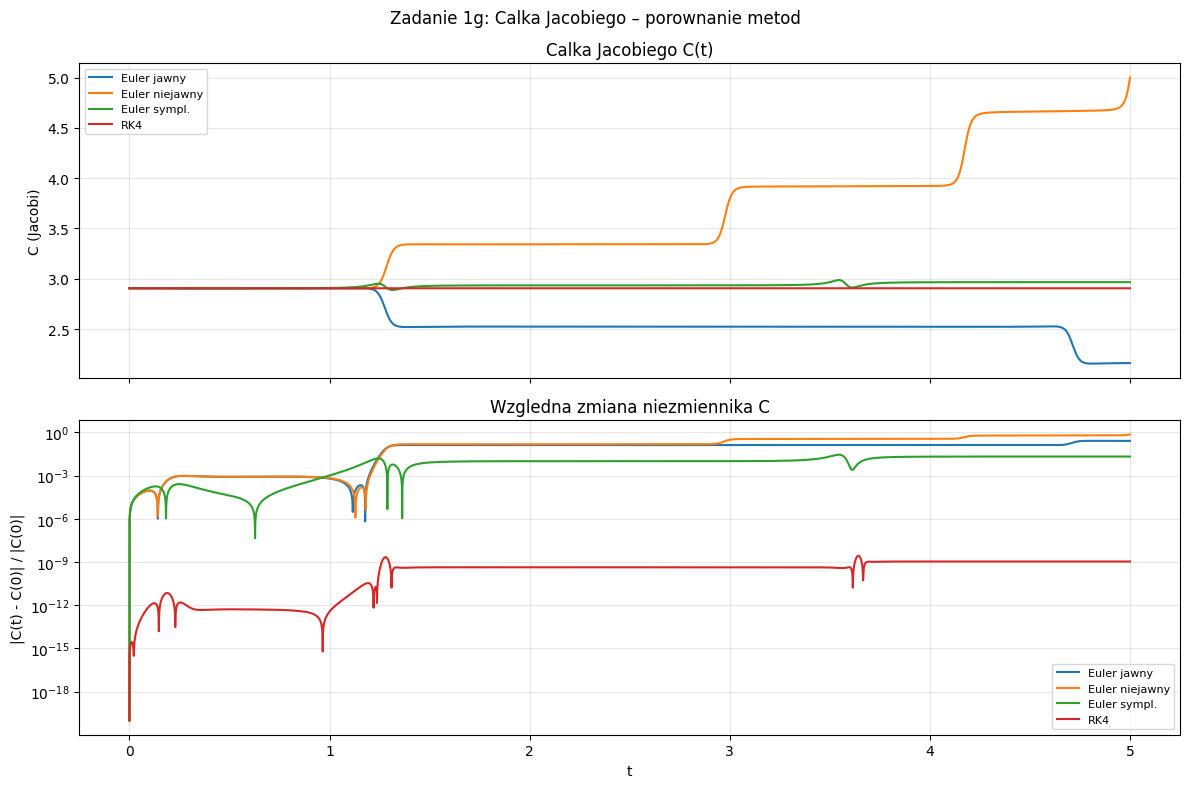

Poczatkowa wartosc calki Jacobiego C(0) = 2.90580042


In [24]:
def compute_jacobi(y_sol, mu=MU):
    """Oblicza calke Jacobiego C dla kazdego kroku."""
    x, y_pos, u, v = y_sol[:, 0], y_sol[:, 1], y_sol[:, 2], y_sol[:, 3]

    r1 = np.sqrt((x + mu)**2       + y_pos**2)
    r2 = np.sqrt((x - 1.0 + mu)**2 + y_pos**2)

    C = x**2 + y_pos**2 + 2.0*(1.0 - mu)/r1 + 2.0*mu/r2 - u**2 - v**2
    return C


def plot_jacobi(results_dict, mu=MU):
    """
    Rysuje wykres calki Jacobiego dla wszystkich metod.
    results_dict: {'nazwa_metody': (t, y_sol)}
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    for name, (t, y_sol) in results_dict.items():
        C  = compute_jacobi(y_sol, mu)
        C0 = C[0]
        axes[0].plot(t, C, label=name)
        rel_err = np.abs(C - C0) / np.abs(C0)
        rel_err[rel_err == 0] = 1e-20   # unikamy log(0)
        axes[1].semilogy(t, rel_err, label=name)

    axes[0].set_ylabel('C (Jacobi)')
    axes[0].set_title('Calka Jacobiego C(t)')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_ylabel('|C(t) - C(0)| / |C(0)|')
    axes[1].set_xlabel('t')
    axes[1].set_title('Wzgledna zmiana niezmiennika C')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, which='both', alpha=0.3)

    plt.suptitle("Zadanie 1g: Calka Jacobiego – porownanie metod")
    plt.tight_layout()
    plt.show()

    C0_val = compute_jacobi(X0.reshape(1, -1))[0]
    print(f"Poczatkowa wartosc calki Jacobiego C(0) = {C0_val:.8f}")

results = {
    'Euler jawny':    (t_exp, y_exp),
    'Euler niejawny': (t_imp, y_imp),
    'Euler sympl.':   (t_sym, y_sym),
    'RK4':            (t_rk4, y_rk4),
}
plot_jacobi(results)